In [135]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [136]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

In [137]:
TEST_NUM = OPTIONS['dynamic_tests']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [138]:
TARGET_VAR  = 'pitch'
TARGET_TIME = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits') 
TARGET_TIME

[15, 1000000000.0]

# IMPORTANDO DADOS

In [139]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,time,tmp,yaw,ax,roll,wx,wz,az,pitch,ay,wy
0,0.000000,60.1,358241,-88449,5192,12354,39332,987371,2151,37455,10327
1,0.048256,59.8,358242,-104433,5193,3885,-4528,987574,2150,54771,-47335
2,0.095500,60.1,358241,-88449,5192,12354,39332,987371,2151,37455,10327
3,0.206316,59.8,358227,-93552,5185,24020,11993,1000172,2140,33186,31529
4,0.298519,59.9,358227,-88595,5187,40461,12328,993350,2145,34643,-13804
...,...,...,...,...,...,...,...,...,...,...,...
3306,330.534400,60.2,1185,-87914,5040,-18226,-20174,995693,2072,35031,-36127
3307,330.631263,60.3,1183,-91207,5040,-12334,-16965,992154,2071,37203,-5895
3308,330.722081,60.3,1183,-82899,5038,-29370,-29412,989165,2074,32763,-25135
3309,330.829164,60.2,1183,-88046,5037,26456,-1304,991438,2073,36961,-12711


- Convertendo pra radianos

In [140]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,time,tmp,yaw,ax,roll,wx,wz,az,pitch,ay,wy
0,0.000000,60.1,358.241,-0.867388,5.192,0.12354,0.39332,9.682802,2.151,0.367308,0.10327
1,0.048256,59.8,358.242,-1.024138,5.193,0.03885,-0.04528,9.684793,2.150,0.537120,-0.47335
2,0.095500,60.1,358.241,-0.867388,5.192,0.12354,0.39332,9.682802,2.151,0.367308,0.10327
3,0.206316,59.8,358.227,-0.917432,5.185,0.24020,0.11993,9.808337,2.140,0.325443,0.31529
4,0.298519,59.9,358.227,-0.868820,5.187,0.40461,0.12328,9.741436,2.145,0.339732,-0.13804


- Formatando as colunas pra ficar igual a de referência

In [141]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,time,tmp,yaw,ax,roll,wx,wz,az,pitch,ay,wy
0,0.000000,60.1,358.241,-0.867388,2.151,0.12354,0.10327,0.367308,-5.192,9.682802,-0.39332
1,0.048256,59.8,358.242,-1.024138,2.150,0.03885,-0.47335,0.537120,-5.193,9.684793,0.04528
2,0.095500,60.1,358.241,-0.867388,2.151,0.12354,0.10327,0.367308,-5.192,9.682802,-0.39332
3,0.206316,59.8,358.227,-0.917432,2.140,0.24020,0.31529,0.325443,-5.185,9.808337,-0.11993
4,0.298519,59.9,358.227,-0.868820,2.145,0.40461,-0.13804,0.339732,-5.187,9.741436,-0.12328


# VISUALIZAÇÃO DE VARIÁVEIS

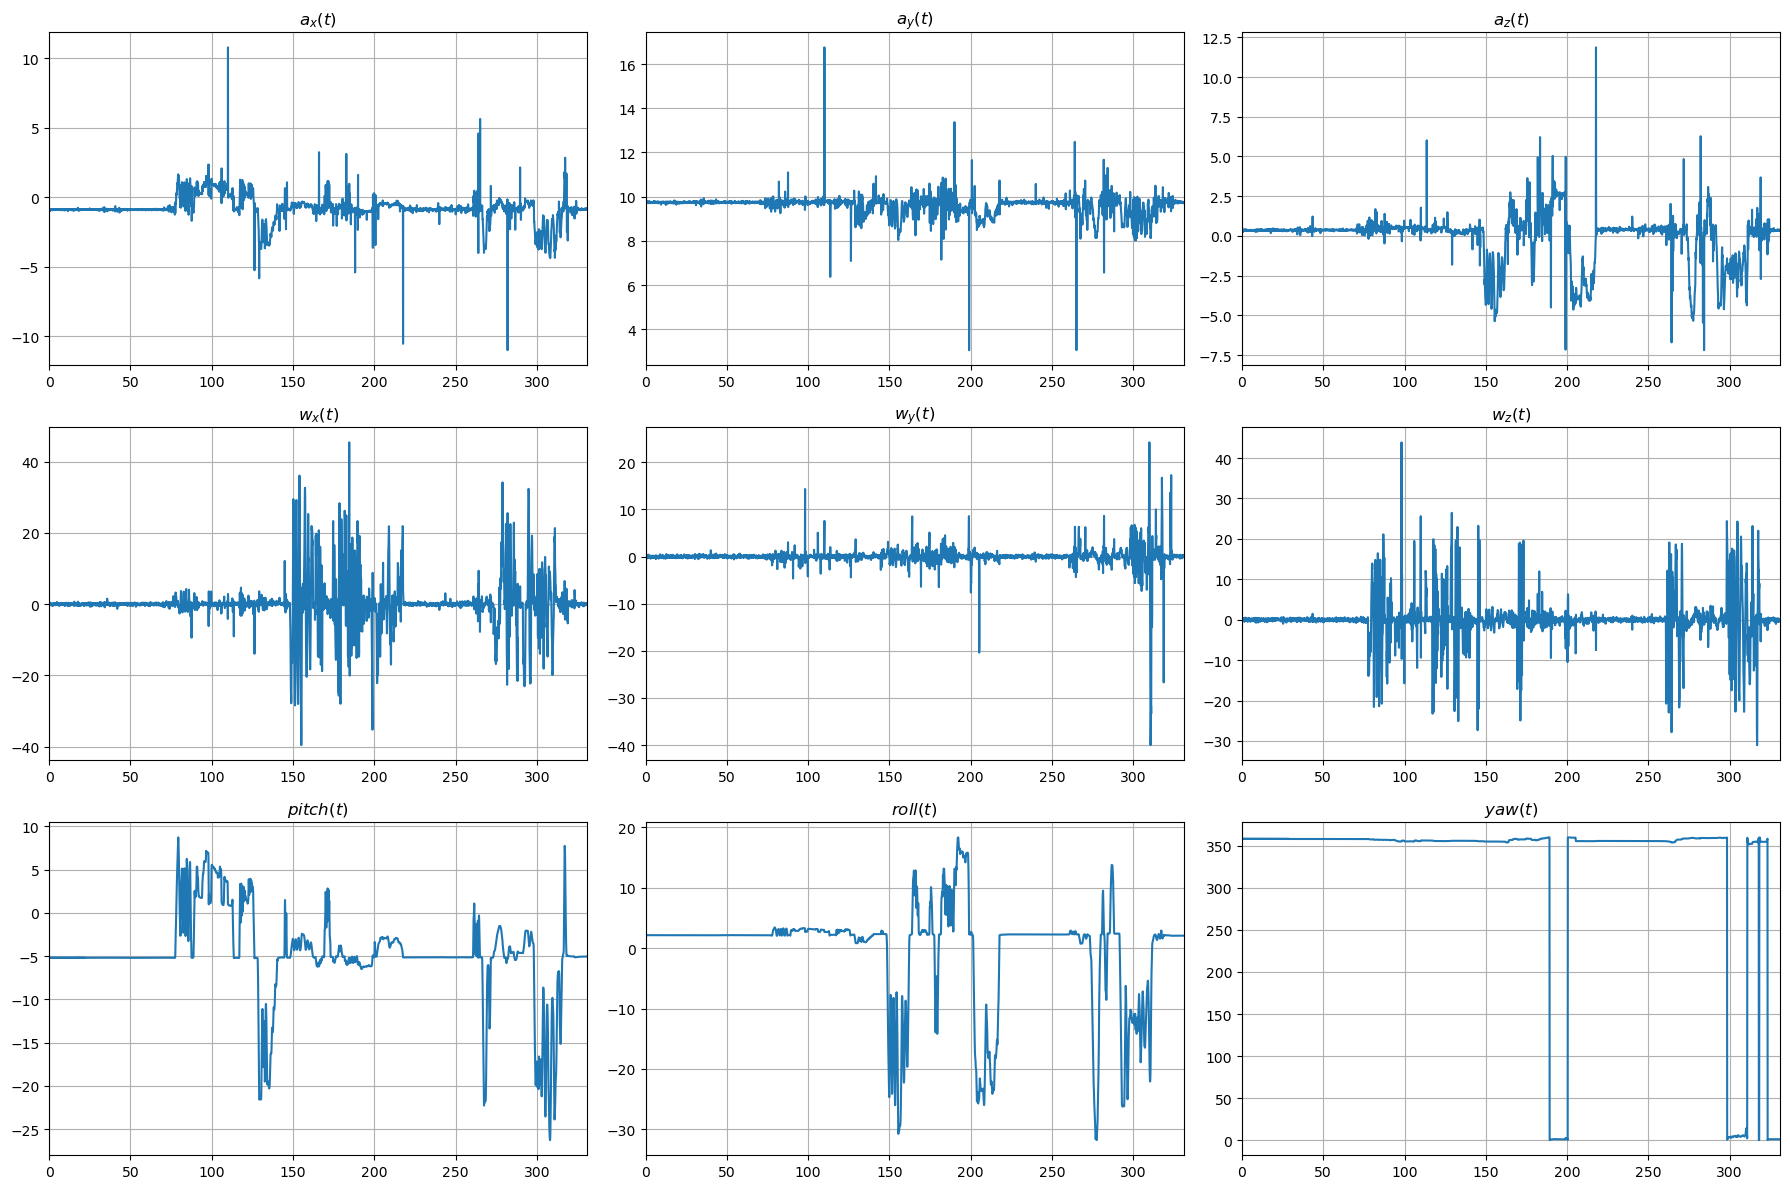

In [142]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

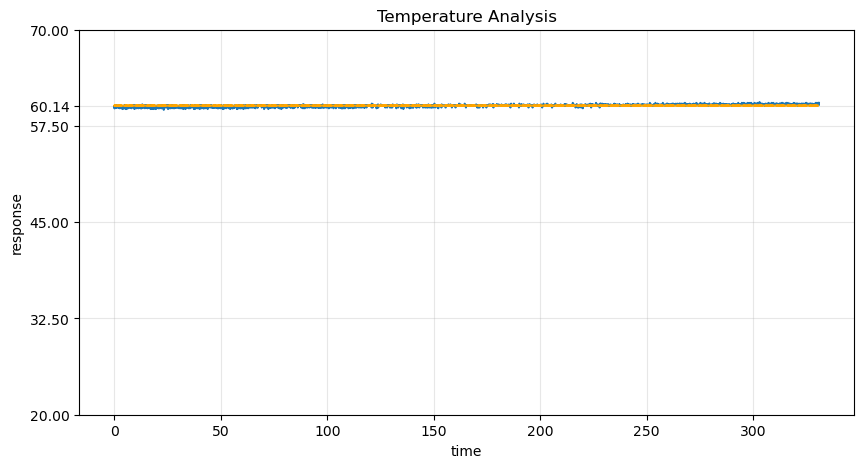

In [143]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

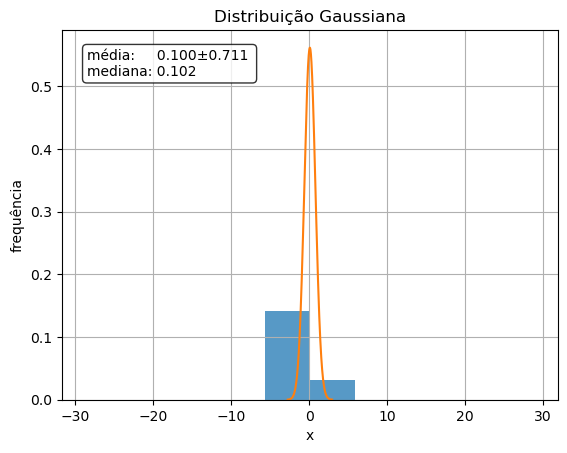

In [144]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [145]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,tmp,yaw,ax,roll,wx,wz,az,pitch,ay,wy
0,0.0,60.1,358.133,-0.905517,2.152,-0.01666,0.22552,0.329562,-5.197,9.760657,-0.26011
1,0.1,60.1,358.241,-0.867388,2.151,0.12354,0.10327,0.367308,-5.192,9.682802,-0.39332
2,0.2,60.1,358.241,-0.867388,2.151,0.12354,0.10327,0.367308,-5.192,9.682802,-0.39332
3,0.3,59.9,358.227,-0.868820,2.145,0.40461,-0.13804,0.339732,-5.187,9.741436,-0.12328
4,0.4,59.9,358.227,-0.868820,2.145,0.40461,-0.13804,0.339732,-5.187,9.741436,-0.12328
...,...,...,...,...,...,...,...,...,...,...,...
3306,330.6,60.2,1.185,-0.862142,2.072,-0.18226,-0.36127,0.343537,-5.040,9.764413,0.20174
3307,330.7,60.3,1.183,-0.894435,2.071,-0.12334,-0.05895,0.364837,-5.040,9.729707,0.16965
3308,330.8,60.3,1.183,-0.812961,2.074,-0.29370,-0.25135,0.321295,-5.038,9.700395,0.29412
3309,330.9,60.2,1.183,-0.863436,2.073,0.26456,-0.12711,0.362464,-5.037,9.722685,0.01304


# FILTRANDO POR VARIAVEL

In [146]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

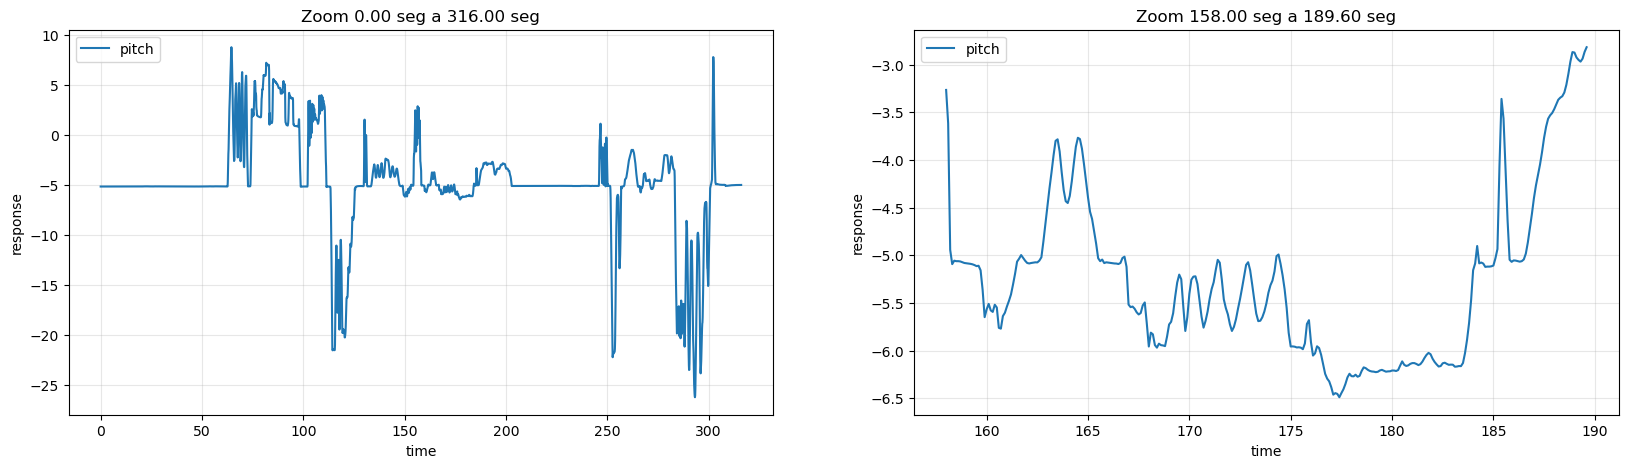

In [147]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [148]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col != 'time'})
df

,time,target_tmp,target_yaw,target_ax,target_roll,target_wx,target_wz,target_az,target_pitch,target_ay,target_wy
150,0.0,59.9,358.186,-0.877783,2.147,0.26370,0.23641,0.372859,-5.197,9.769365,0.09422
151,0.1,60.2,358.185,-0.920825,2.147,-0.10443,-0.33141,0.332681,-5.197,9.757254,-0.00270
152,0.2,59.9,358.185,-0.944125,2.146,0.14189,-0.37010,0.371721,-5.195,9.736817,0.10629
153,0.3,59.9,358.185,-0.971633,2.147,0.20449,-0.62399,0.360561,-5.195,9.791842,0.14559
154,0.4,59.9,358.183,-0.892866,2.149,0.19343,-0.12722,0.350499,-5.196,9.751056,0.19675
...,...,...,...,...,...,...,...,...,...,...,...
3306,315.6,60.2,1.185,-0.862142,2.072,-0.18226,-0.36127,0.343537,-5.040,9.764413,0.20174
3307,315.7,60.3,1.183,-0.894435,2.071,-0.12334,-0.05895,0.364837,-5.040,9.729707,0.16965
3308,315.8,60.3,1.183,-0.812961,2.074,-0.29370,-0.25135,0.321295,-5.038,9.700395,0.29412
3309,315.9,60.2,1.183,-0.863436,2.073,0.26456,-0.12711,0.362464,-5.037,9.722685,0.01304


In [149]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)